# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Business Objectives

##### Background
The used car market is competitive and dynamic. Dealerships must optimize their inventory by acquiring vehicles that consumers value and pricing them accurately to ensure quick turnover and maximize profitability.

##### Business Goal
Identify the primary drivers of used car prices. Specifically, determine which attributes (e.g., mileage, age, brand, fuel type) command a premium.

##### Business Success Criteria
Provide clear, actionable recommendations to the dealership's inventory acquisition team regarding which vehicle types, brands, and specifications to stock and how to estimate their market value.

#### Data Mining Goals

Use supervised machine learning to train multiple regression models using cross-validation and hyperparameter grid searches with the goal of minimizing error metrics (MAE, RMSE). The goal is to identify coefficients and feature importance of the various quantitative features (e.g., `year`, `odometer`) and categorical features (e.g., `manufacturer`, `model`, `condition`, `fuel`, `transmission`, `type`) as it relates to the target variable (`price`).

Extract and interpret model coefficients and feature importances to quantify the impact of each feature on used car prices.


#### Project Plan

##### Data Understanding
Analyze features, visualize distributions, identify missing data, and detect outliers.

##### Data Preparation
Decide whether to impute or drop missing data, remove price and odometer outliers, perform feature engineering, and encode categorical variables.

##### Modeling
Build baseline and regularized regression models (Ridge/Lasso) with hyperparameter tuning.

##### Evaluation
Evaluate models using cross-validation, interpret coefficients, and check alignment with business goals.

##### Deployment
Present findings in a clear, non-technical summary report for the dealership management team.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### **Data Understanding Goals**
During this phase, we aim to familiarize ourselves with the dataset to identify quality issues and uncover preliminary insights that will inform our modeling. We will:
1. **Load and Profile the Dataset:** Check shape, data types, and basic structure.
2. **Assess Data Quality:** Quantify missing values, duplicate records, and identify structural inconsistencies.
3. **Analyze Descriptive Statistics:** Identify outliers, range of values, and potential errors (e.g., zero-priced cars).
4. **Perform Exploratory Data Analysis (EDA):** Use visualizations to examine relationships between continuous features (price, age, mileage) and categorical attributes (fuel type, transmission, manufacturer).

#### **Dataset Features Description**
* `id` / `VIN`: Unique identifiers (not predictive of price).
* `price` (Target): Resale price of the used car in USD.
* `year` / `odometer`: Age of the car and mileage (key continuous predictors).
* `manufacturer` / `model`: Brand and specific vehicle make.
* `condition` / `title_status` / `paint_color`: Qualitative assessments of vehicle state.
* `cylinders` / `fuel` / `transmission` / `drive` / `size` / `type`: Mechanical specifications of the car.
* `region` / `state`: Geographical variables indicating listing location.


In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Output shape and preview of types
print("Dataset Shape (Rows, Columns):", df.shape)
df.info()


Dataset Shape (Rows, Columns): (426880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  stat

#### **Interpretation of Shape and Schema**
* The dataset contains $426,880$ rows and $18$ columns. This is a substantial sample size, providing high statistical power for modeling.
* **Feature Types:**
  * **Numerical:** `price` (integer), `year` (float), `odometer` (float). Note that `year` should logically be treated as integer data.
  * **Categorical:** 14 columns are text-based (`object`), representing nominal features (e.g., `manufacturer`, `fuel`) and ordinal features (e.g., `condition`).
  * **Identifiers:** `id` and `VIN` are unique ID columns. `VIN` has a high cardinality and requires specific consideration.


In [31]:
# Calculate counts and percentages of missing values per column
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Consolidate into a data quality DataFrame
data_quality_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print("=== Column Missing data Summary ===")
print(data_quality_df)

# Check for duplicate entries (excluding ID, which is always unique)
duplicate_count = df.duplicated(subset=df.columns.difference(['id'])).sum()
print(f"\nNumber of duplicate rows (excluding 'id'): {duplicate_count}")


=== Column Missing data Summary ===
              Missing Count  Percentage (%)
size                 306361       71.767476
cylinders            177678       41.622470
condition            174104       40.785232
VIN                  161042       37.725356
drive                130567       30.586347
paint_color          130203       30.501078
type                  92858       21.752717
manufacturer          17646        4.133714
title_status           8242        1.930753
model                  5277        1.236179
odometer               4400        1.030735
fuel                   3013        0.705819
transmission           2556        0.598763
year                   1205        0.282281
id                        0        0.000000
region                    0        0.000000
price                     0        0.000000
state                     0        0.000000

Number of duplicate rows (excluding 'id'): 56202


#### **Interpretation of Data Quality (Missing data and Integrity)**
* **High level of Missing data (>30%):**
Dropping rows with missing values in the columns below would result in losing a significant percentage of our dataset. We will either need robust imputation strategies (such as mode-imputation by vehicle type or grouping) or create a distinct `'missing'` indicator during data preparation. The `size` column should be dropped due to the very high percentage of missing values.
  * `size` (71.77% missing)
  * `cylinders` (41.62% missing)
  * `condition` (40.79% missing)
  * `VIN` (37.73% missing)
  * `drive` (30.59% missing)
  * `paint_color` (30.50% missing).

* **Low level of Missing data (<5%):**
The following features have minimal missing data. For these, simple imputation or dropping missing rows is acceptable.
  * `year` (0.28%)
  * `odometer` (1.03%)
  * `fuel` (0.71%)
  * `transmission` (0.60%)

* **Duplicates:** Excluding the unique id, there are $56,202$ duplicate rows. These will be retained for modeling as they represent identical vehicles listed multiple times, which is typical in auto listings.


In [32]:
# Standard numerical statistics
print("=== Summary Statistics for Numerical Columns ===")
print(df[['price', 'year', 'odometer']].describe().round(2))

# Investigate outliers and extreme values for price
print("\n=== Detailed Price Quantiles ===")
print(df['price'].quantile([0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]).apply(lambda x: f"${x:,.2f}"))

# Investigate outliers and extreme values for odometer
print("\n=== Detailed Odometer Quantiles ===")
print(df['odometer'].quantile([0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]).apply(lambda x: f"{x:,.1f} miles"))


=== Summary Statistics for Numerical Columns ===
              price       year     odometer
count  4.268800e+05  425675.00    422480.00
mean   7.519903e+04    2011.24     98043.33
std    1.218228e+07       9.45    213881.50
min    0.000000e+00    1900.00         0.00
25%    5.900000e+03    2008.00     37704.00
50%    1.395000e+04    2013.00     85548.00
75%    2.648575e+04    2017.00    133542.50
max    3.736929e+09    2022.00  10000000.00

=== Detailed Price Quantiles ===
0.000                $0.00
0.010                $0.00
0.050                $0.00
0.100              $500.00
0.250            $5,900.00
0.500           $13,950.00
0.750           $26,485.75
0.900           $37,590.00
0.950           $44,500.00
0.990           $66,995.00
0.999          $120,000.00
1.000    $3,736,928,711.00
Name: price, dtype: object

=== Detailed Odometer Quantiles ===
0.000             0.0 miles
0.010             2.0 miles
0.050         6,318.0 miles
0.100        14,939.0 miles
0.250        37,704.0

#### **Interpretation of Statistics and Anomalies**
* **Price Anomalies:** 
  * The median price is **$13,950** and the 75th percentile is **$26,485**. However, the minimum price is **$0** (representing at least 32,895 entries) and the maximum price is a staggering **$3,736,928,686**.
  * Listings with a price of $0 or token amounts (e.g., $1 or $5) represent incomplete postings, unpaid loans, or search optimization tags. On the upper end, prices above $100,000 contain data entry mistakes or extreme luxury collector cars. Both extremes will skew regression models and must be pruned.
* **Odometer Anomalies:**
  * The median mileage is **85,548 miles**. The maximum odometer reading is **10,000,000 miles**, which is an obvious typing error. The minimum is **0 miles**, which could represent new cars but also potential data issues.
* **Year Ranges:**
  * Listing years range from **1900 to 2022**. Classic cars usually follow a different pricing logic (valuing rarity and age) compared to modern used cars, which depreciate as they age. We should separate classic cars or restrict our model to modern consumer cars (post 1990).


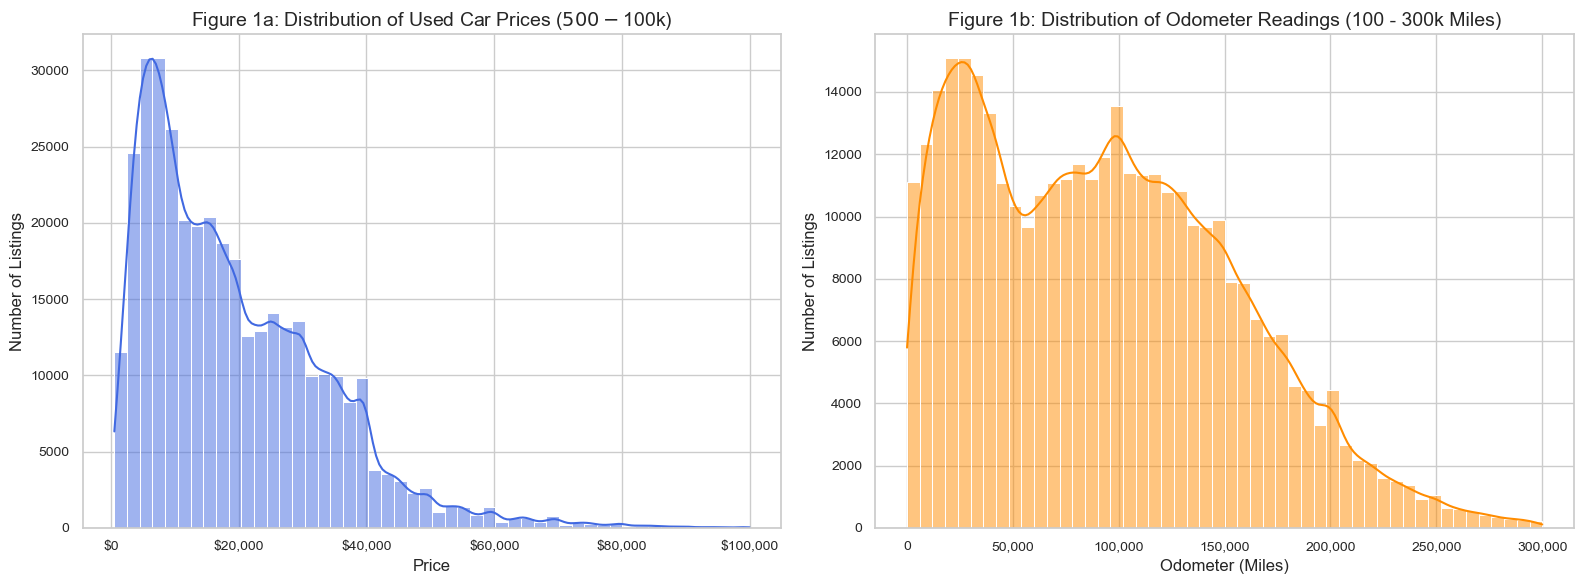

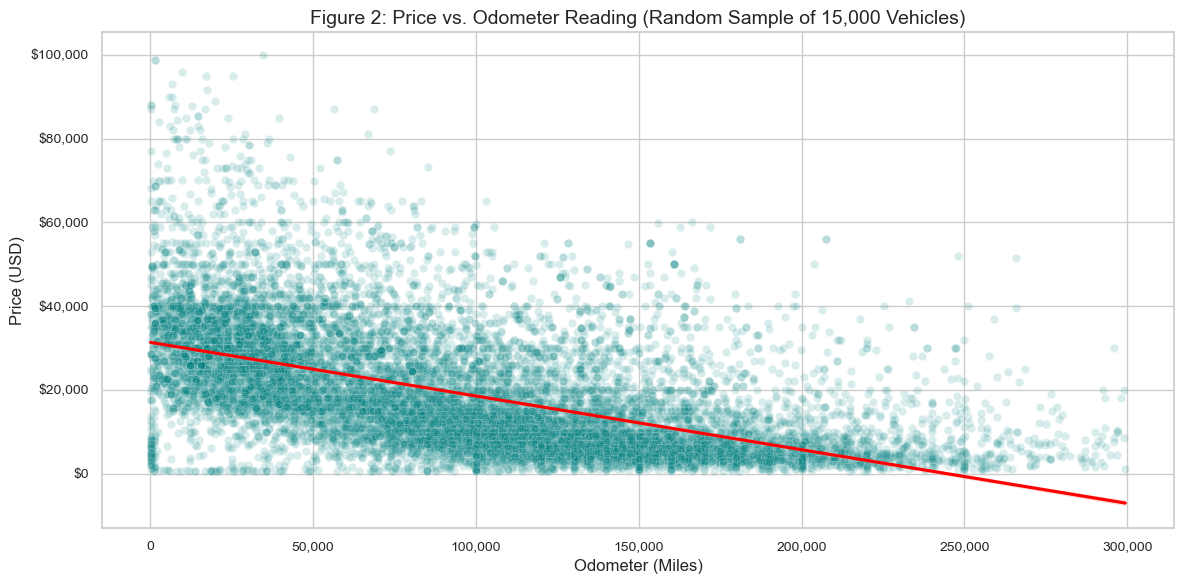

In [33]:
# Set visual theme for premium design, readability, and clean aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100
})

# Create a copy with realistic thresholds for visual analysis.
# remove price outliers
df_viz = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
# remove odometer outliers
df_viz = df_viz[(df_viz['odometer'] > 100) & (df_viz['odometer'] < 300000)]
# remove classic cars
df_viz = df_viz[df_viz['year'] > 1990]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distribution of Price
sns.histplot(df_viz['price'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Figure 1a: Distribution of Used Car Prices ($500 - $100k)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of Listings')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

# Subplot 2: Distribution of Odometer
sns.histplot(df_viz['odometer'], bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Figure 1b: Distribution of Odometer Readings (100 - 300k Miles)')
axes[1].set_xlabel('Odometer (Miles)')
axes[1].set_ylabel('Number of Listings')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# Relationship between Price and Odometer (Sampled to restrict points plotted to a reasonable number)
df_sample = df_viz.sample(15000)
sns.scatterplot(data=df_sample, x='odometer', y='price', alpha=0.15, color='teal')
sns.regplot(data=df_sample, x='odometer', y='price', scatter=False, color='red')
plt.title('Figure 2: Price vs. Odometer Reading (Random Sample of 15,000 Vehicles)')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.show()


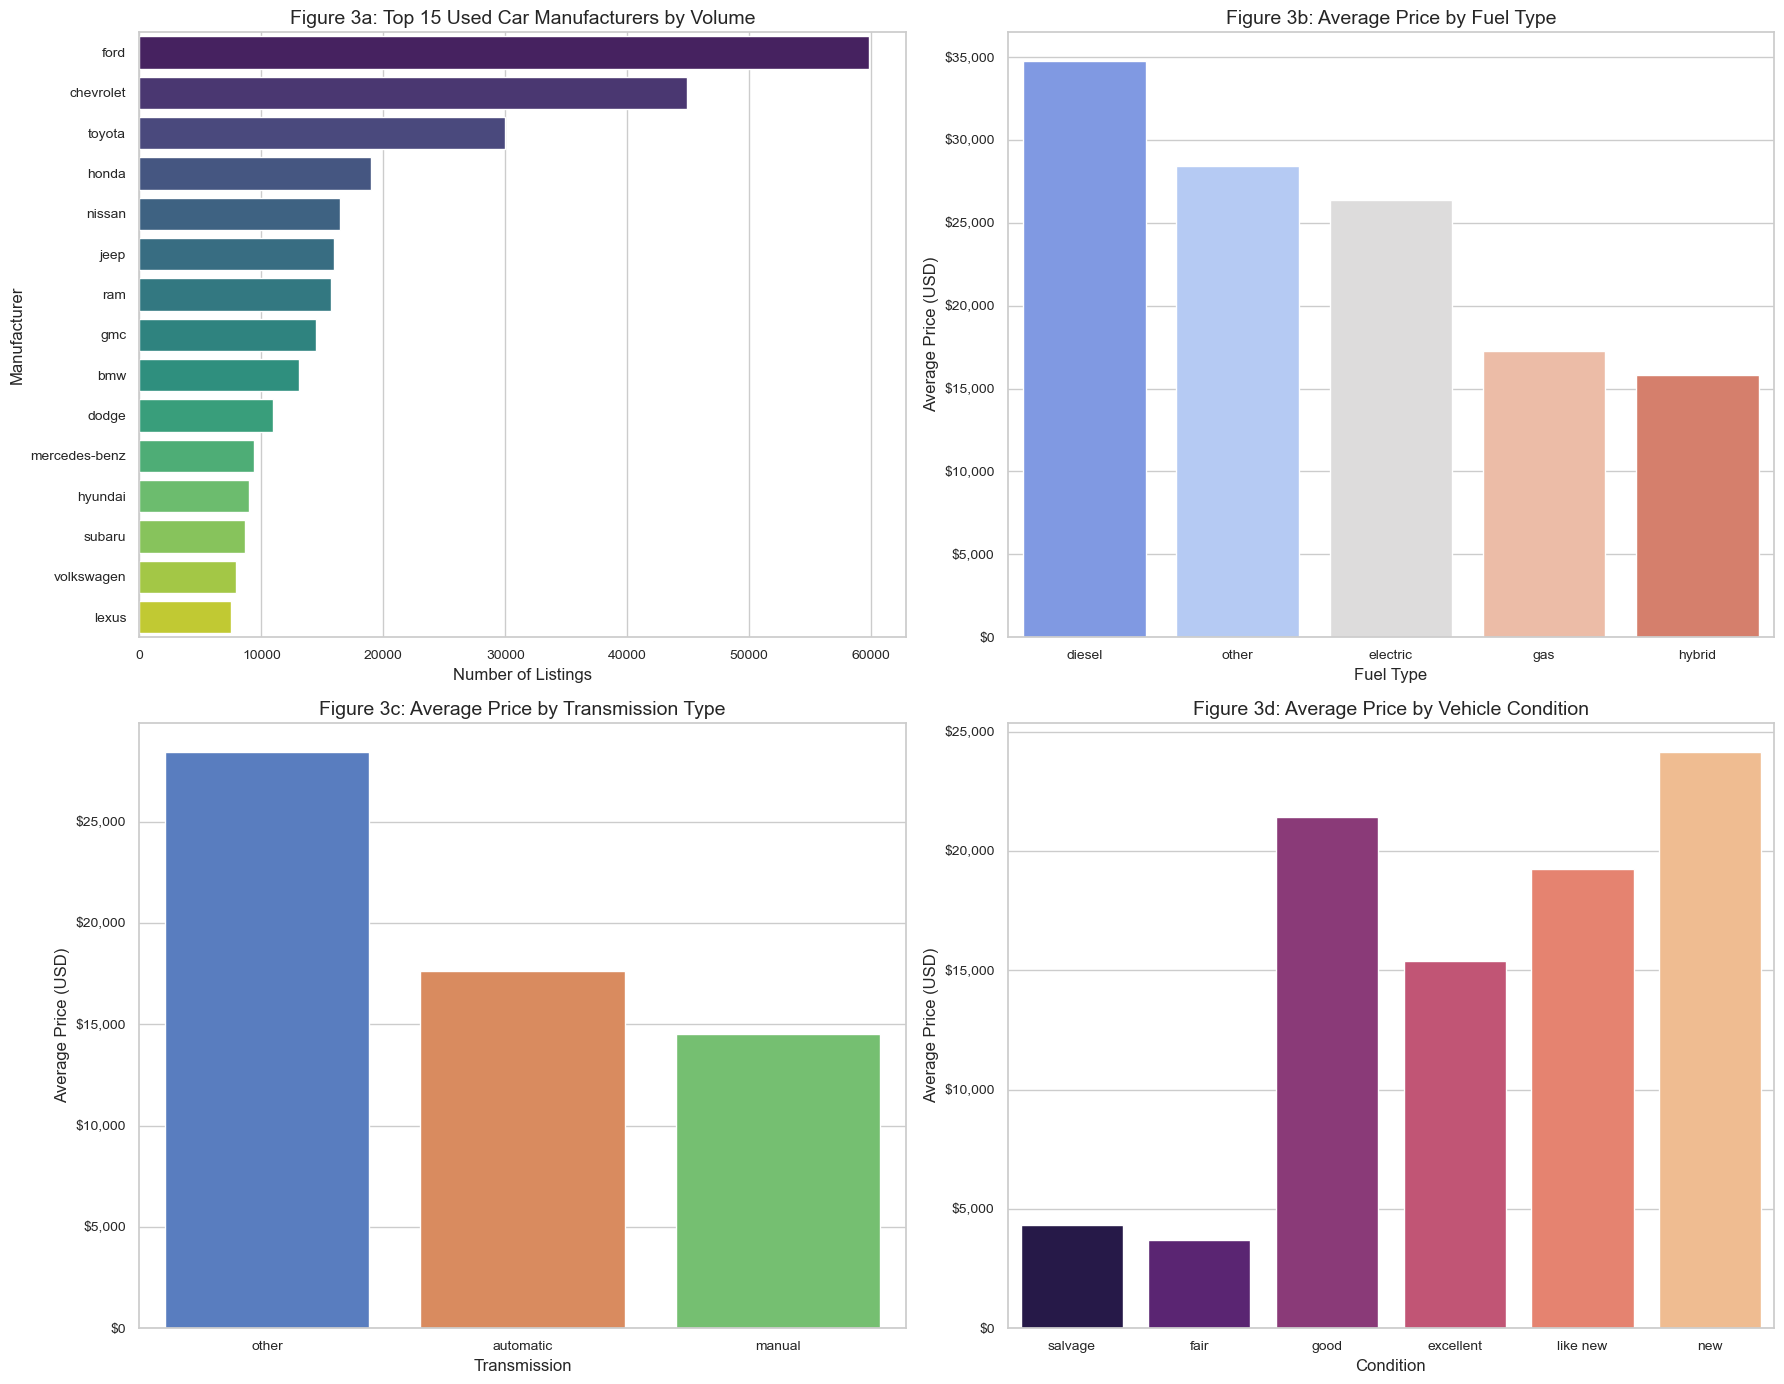

In [34]:
# Set up a 2x2 panel of categorical distributions and average prices
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 15 Manufacturers by Listing Volume
top_manufacturers = df_viz['manufacturer'].value_counts().head(15).index
sns.countplot(data=df_viz[df_viz['manufacturer'].isin(top_manufacturers)],
              y='manufacturer',
              order=top_manufacturers,
              ax=axes[0, 0],
              palette='viridis',
              legend=False)
axes[0, 0].set_title('Figure 3a: Top 15 Used Car Manufacturers by Volume')
axes[0, 0].set_xlabel('Number of Listings')
axes[0, 0].set_ylabel('Manufacturer')

# Average Price by Fuel Type
avg_price_fuel = df_viz.groupby('fuel')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_viz,
            x='fuel',
            y='price',
            ax=axes[0, 1],
            errorbar=None,
            order=avg_price_fuel,
            palette='coolwarm',
            legend=False)
axes[0, 1].set_title('Figure 3b: Average Price by Fuel Type')
axes[0, 1].set_xlabel('Fuel Type')
axes[0, 1].set_ylabel('Average Price (USD)')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

# Average Price by Transmission Type
avg_price_trans = df_viz.groupby('transmission')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_viz, 
            x='transmission',
            y='price',
            ax=axes[1, 0],
            errorbar=None,
            order=avg_price_trans,
            hue='transmission',
            legend=False)
axes[1, 0].set_title('Figure 3c: Average Price by Transmission Type')
axes[1, 0].set_xlabel('Transmission')
axes[1, 0].set_ylabel('Average Price (USD)')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

# 4. Average Price by Condition
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
sns.barplot(data=df_viz,
            x='condition',
            y='price',
            ax=axes[1, 1],
            errorbar=None,
            order=condition_order,
            palette='magma',
            legend=False)
axes[1, 1].set_title('Figure 3d: Average Price by Vehicle Condition')
axes[1, 1].set_xlabel('Condition')
axes[1, 1].set_ylabel('Average Price (USD)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

plt.tight_layout()
plt.show()


#### **EDA Interpretation**
1. **Price vs Mileage:** Figure 2 displays a clear, negative relationship showing that higher mileage (odometer) correlates with a decrease in vehicle price. This represents standard vehicle depreciation and will likely be a major coefficient in our modeling.
2. **Market Volume Dominance:** Ford and Chevrolet represent the highest number of listings. Our model will be highly influenced by their pricing structures.
3. **Premium Fuel Types:** Diesel vehicles command a significant average price premium over gas, hybrid, and electric vehicles (**Figure 3b**), indicating high resale value retention for work trucks and heavy-duty vehicles.
4. **Transmission Premium:** "Other" transmissions carry the highest average prices, whereas manual transmissions are the cheapest, reflecting their decline in modern consumer vehicles. (**Figure 3c**).
5. **Condition Grading:** Prices scale linearly with condition quality (salvage -> new), confirming that condition should be handled ordinally during encoding (**Figure 3d**).

#### **Data Preparation Action Items**
To ready the dataset for regression modeling, we must address the following issues identified during this phase:
1. **Filter Outliers:** Filter the dataset to include prices between `$500` and `$100,000`, odometer values between `100` and `300,000` miles, and registration years after `1990`.
2. **Feature Removal:** Drop irrelevant identifiers (`id`, `VIN`) and columns with excessive missingness (like `size` with 71.77% missing) to avoid sparse matrices.
3. **Imputation:** Apply mode-imputation or fill missing categorical slots with a new `'missing'` category to avoid dropping valuable rows.
4. **Encoding:** Apply one-hot encoding to low-cardinality categories (`fuel`, `transmission`, `condition`, `drive`) and target encoding or grouping for high-cardinality columns like `manufacturer` and `model`.


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

#### Data Preparation Goals & Strategy
During this phase, we clean and prepare our dataset for regression modeling. Based on our findings in the Data Understanding phase, we will implement the following steps:
1. **Outlier and Classic Car Filtering:** We restrict our dataset to listings with prices between `$500` and `$100,000`, odometer readings between `100` and `300,000` miles, and years after `1990` to remove junk data, classic car pricing dynamics, and obvious typos.
2. **Feature Pruning:** Drop unique identifiers (`id`, `VIN`) and columns with excessive missing data (`size` with 71.77% missing).
3. **Advanced Imputation:**
   - Drop rows with null values in features with very low missing data (<5%) to maintain maximum clean sample size.
   - Impute missing specifications (`cylinders`, `drive`, `type`) by calculating the most frequent category (mode) for each specific vehicle `model`.
   - Impute subjective categories like `paint_color` and `condition` with a `'missing'` placeholder, and fill `title_status` nulls with its global mode.
4. **Feature Engineering:** Calculate vehicle `age` from `year` (using $2021$ as the benchmark year) and drop the raw `year` column.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Reload the dataset to ensure a clean start
df = pd.read_csv('data/vehicles.csv')

# 1. Apply outlier filtering
df_cleaned = df[
    (df['price'] >= 500) & (df['price'] <= 100000) &
    (df['odometer'] >= 100) & (df['odometer'] <= 300000) &
    (df['year'] >= 1990)
].copy()

# 2. Drop unique identifiers and columns with excessive missingness
df_cleaned = df_cleaned.drop(columns=['id', 'VIN', 'size'])

# 3. Drop rows with null values in key columns with low missingness (<5%)
key_cols = ['year', 'odometer', 'fuel', 'transmission', 'manufacturer', 'model']
df_cleaned = df_cleaned.dropna(subset=key_cols)

# 4. Group-based Mode Imputation helper function
def impute_mode_by_group(df, target_col, group_col):
    # create counts dataframe for target_col, group_col pairs
    counts = df.groupby([group_col, target_col]).size().reset_index(name='count')
    sorted_counts = counts.sort_values([group_col, 'count'], ascending=[True, False])
    # mode_map contains the target_col mode for each group_col value
    mode_map = sorted_counts.drop_duplicates(subset=[group_col]).set_index(group_col)[target_col]
    
    # Global mode for group_col in case a model has no mode
    global_mode = df[target_col].mode()[0]

    imputed_vals = df[group_col].map(mode_map).fillna(global_mode)
    df[target_col] = df[target_col].fillna(imputed_vals)
    return df

df_cleaned = impute_mode_by_group(df_cleaned, 'cylinders', 'model')
df_cleaned = impute_mode_by_group(df_cleaned, 'drive', 'model')
df_cleaned = impute_mode_by_group(df_cleaned, 'type', 'model')

# Fill remaining categoricals with appropriate placeholders/modes
df_cleaned['paint_color'] = df_cleaned['paint_color'].fillna('missing')
df_cleaned['condition'] = df_cleaned['condition'].fillna('missing')
df_cleaned['title_status'] = df_cleaned['title_status'].fillna(df_cleaned['title_status'].mode()[0])

# 5. Feature Engineering: Vehicle Age
df_cleaned['age'] = 2021 - df_cleaned['year']
df_cleaned = df_cleaned.drop(columns=['year'])

print("Cleaned Dataset Shape:", df_cleaned.shape)
print("Missing Values Remaining:\n", df_cleaned.isnull().sum())

Cleaned Dataset Shape: (345436, 15)
Missing Values Remaining:
 region          0
price           0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
age             0
dtype: int64


#### Handling High-Cardinality & Preventing Data Leakage
Several nominal categorical features exhibit extremely high cardinality:
* `model`: ~19,600 unique values
* `region`: ~400 unique values
* `state`: 51 unique values
* `manufacturer`: 40 unique values

Using standard one-hot encoding on these features would generate over 20,000 columns, causing severe sparse-matrix dimensionality issues and out-of-memory errors.

To resolve this, we will use **Target Encoding** (mean encoding) for these four high-cardinality features. Each category is replaced with the mean target value (`price`) of that category.

**Critical Prevention of Data Leakage:**
To prevent target leakage, target encoding must be calculated **strictly using the training set (`y_train`)** and then mapped onto the test set. Any unseen category in the test set will be filled using the global training mean.

In [36]:
# Separate features and target
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

# Train-test split (70% train, 30% test) to prepare for target encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply manual target encoding for high-cardinality variables
high_card_cols = ['model', 'manufacturer', 'region', 'state']

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col in high_card_cols:
    # Compute mean target value solely on the training set
    category_means = y_train.groupby(X_train[col]).mean()
    global_mean = y_train.mean()
    
    # Map to both training and test datasets
    X_train_encoded[col] = X_train_encoded[col].map(category_means).fillna(global_mean)
    X_test_encoded[col] = X_test_encoded[col].map(category_means).fillna(global_mean)

print("X_train shape after target encoding:", X_train_encoded.shape)
print("X_test shape after target encoding:", X_test_encoded.shape)

X_train shape after target encoding: (241805, 14)
X_test shape after target encoding: (103631, 14)


#### Feature Scaling and One-Hot Encoding
After converting high-cardinality variables into numerical target means, we assemble our preprocessing pipeline:
1. **Numerical Standardization (`StandardScaler`):** Applied to numerical features (`age`, `odometer`) and target-encoded features (`model`, `manufacturer`, `region`, `state`) to ensure models like Ridge and Lasso are regularized equitably.
2. **One-Hot Encoding (`OneHotEncoder`):** Applied to the remaining low-cardinality nominal and categorical features (`fuel`, `transmission`, `drive`, `type`, `paint_color`, `condition`, `title_status`, `cylinders`).

In [37]:
# Define continuous features (including target-encoded features)
num_features = ['age', 'odometer', 'model', 'manufacturer', 'region', 'state']

# Define categorical features for One-Hot Encoding
low_card_features = ['fuel', 'transmission', 'drive', 'type', 'paint_color', 'condition', 'title_status', 'cylinders']

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('low_card', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), low_card_features)
    ]
)

# Fit-transform train set and transform test set
X_train_processed = preprocessor.fit_transform(X_train_encoded)
X_test_processed = preprocessor.transform(X_test_encoded)

# Get feature names for interpretability later
feature_names = num_features + list(preprocessor.named_transformers_['low_card'].get_feature_names_out(low_card_features))

print("Final X_train processed dimensions (Rows, Features):", X_train_processed.shape)
print("Final X_test processed dimensions (Rows, Features):", X_test_processed.shape)
print("Number of engineered features:", len(feature_names))

Final X_train processed dimensions (Rows, Features): (241805, 56)
Final X_test processed dimensions (Rows, Features): (103631, 56)
Number of engineered features: 56


#### Data Preparation Summary
* **Sample Preservation:** Dropping entries listwise only for features with $<5\%$ missingness, coupled with group-mode imputation, preserved **$345,436$ rows** out of $426,880$ original listings (~$81\%$).
* **Feature Count:** Target encoding high-cardinality nominals kept the post-processed feature matrix size extremely efficient, containing only **56 dimensions** (features) compared to the $20,000+$ features we would have generated using standard One-Hot Encoding. This guarantees stable and rapid training in our **Modeling** phase.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### Modeling Goals & Strategy
In this phase, we build and compare multiple regression models to predict used car prices and identify their primary drivers. The features have been scaled using `StandardScaler` to have a mean of 0 and variance of 1, which is necessary for regularized regression models to compute their penalty terms fairly.

We will train and compare:
1. **Ordinary Least Squares (OLS) Linear Regression:** Serving as our baseline model.
2. **Ridge Regression (`RidgeCV`):** Adding L2 regularization to control for multicollinearity (e.g., between vehicle `age` and mileage `odometer`). We explore a grid of alpha values: `[0.1, 1.0, 10.0, 100.0, 1000.0]`.
3. **Lasso Regression (`GridSearchCV`):** Adding L1 regularization, which performs automatic feature selection by shrinking less important coefficients to zero. We tune the penalty term (`alpha`) across `[0.1, 1.0, 10.0]` with 3-fold cross-validation.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. OLS Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predict
y_pred_train_lr = lr_model.predict(X_train_processed)
y_pred_test_lr = lr_model.predict(X_test_processed)

# Evaluation
lr_metrics = {
    'Model': 'Linear Regression (OLS)',
    'Train MAE': mean_absolute_error(y_train, y_pred_train_lr),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_lr),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_lr)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_lr)),
    'Train R2': r2_score(y_train, y_pred_train_lr),
    'Test R2': r2_score(y_test, y_pred_test_lr)
}
print("OLS Baseline Performance:")
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:,.4f}")

OLS Baseline Performance:
  Train MAE: 4,110.2249
  Test MAE: 4,303.9842
  Train RMSE: 6,212.9007
  Test RMSE: 6,589.9632
  Train R2: 0.8062
  Test R2: 0.7805


In [39]:
from sklearn.linear_model import RidgeCV

# 2. Ridge Regression with RidgeCV
# Explore alphas: 0.1, 1.0, 10.0, 100.0, 1000.0
alphas_ridge = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_cv.fit(X_train_processed, y_train)

# Predict
y_pred_train_ridge = ridge_cv.predict(X_train_processed)
y_pred_test_ridge = ridge_cv.predict(X_test_processed)

# Evaluation
ridge_metrics = {
    'Model': 'Ridge Regression (RidgeCV)',
    'Train MAE': mean_absolute_error(y_train, y_pred_train_ridge),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_ridge),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_ridge)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_ridge)),
    'Train R2': r2_score(y_train, y_pred_train_ridge),
    'Test R2': r2_score(y_test, y_pred_test_ridge)
}
print(f"RidgeCV (Best Alpha = {ridge_cv.alpha_}) Performance:")
for k, v in ridge_metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:,.4f}")

RidgeCV (Best Alpha = 1.0) Performance:
  Train MAE: 4,110.2050
  Test MAE: 4,303.9882
  Train RMSE: 6,212.9012
  Test RMSE: 6,589.9852
  Train R2: 0.8062
  Test R2: 0.7805


In [40]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# 3. Lasso Regression with GridSearchCV
# Explore alphas: 0.1, 1.0, 10.0
# We set tol=0.01 and max_iter=1000 for fast convergence on large datasets
lasso_param_grid = {'alpha': [0.1, 1.0, 10.0]}
lasso_base = Lasso(max_iter=1000, tol=0.01, random_state=42)
lasso_gs = GridSearchCV(lasso_base, lasso_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train_processed, y_train)

# Best estimator
best_lasso = lasso_gs.best_estimator_

# Predict
y_pred_train_lasso = best_lasso.predict(X_train_processed)
y_pred_test_lasso = best_lasso.predict(X_test_processed)

# Evaluation
lasso_metrics = {
    'Model': 'Lasso Regression (GridSearchCV)',
    'Train MAE': mean_absolute_error(y_train, y_pred_train_lasso),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_lasso),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_lasso)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_lasso)),
    'Train R2': r2_score(y_train, y_pred_train_lasso),
    'Test R2': r2_score(y_test, y_pred_test_lasso)
}
print(f"Lasso (Best Alpha = {lasso_gs.best_params_['alpha']}) Performance:")
for k, v in lasso_metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:,.4f}")

Lasso (Best Alpha = 0.1) Performance:
  Train MAE: 4,110.0734
  Test MAE: 4,303.9706
  Train RMSE: 6,212.9205
  Test RMSE: 6,590.0999
  Train R2: 0.8062
  Test R2: 0.7805


In [41]:
# 4. Create and display a comparison table for the models
modeling_results = pd.DataFrame([lr_metrics, ridge_metrics, lasso_metrics])
print("=== MODEL PERFORMANCE SUMMARY ===")
print(modeling_results.to_string(index=False))

=== MODEL PERFORMANCE SUMMARY ===
                          Model   Train MAE    Test MAE  Train RMSE   Test RMSE  Train R2  Test R2
        Linear Regression (OLS) 4110.224900 4303.984155 6212.900708 6589.963191  0.806176 0.780512
     Ridge Regression (RidgeCV) 4110.205019 4303.988214 6212.901231 6589.985215  0.806176 0.780510
Lasso Regression (GridSearchCV) 4110.073405 4303.970573 6212.920537 6590.099854  0.806174 0.780502


In [44]:
# 5. Extract Ridge Regression coefficients for feature interpretation
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_cv.coef_
})

# Add absolute magnitude column
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)

print(f"Model Intercept (Baseline Price): ${ridge_cv.intercept_:,.2f}\n")

print("=== Top 15 Positive Price Drivers (Command a Premium) ===")
print(coef_df_sorted.head(15).to_string(index=False))

print("\n=== Top 15 Negative Price Drivers (Accelerate Depreciation) ===")
print(coef_df_sorted.tail(15).to_string(index=False))


Model Intercept (Baseline Price): $30,842.20

=== Top 15 Positive Price Drivers (Command a Premium) ===
               Feature  Coefficient  Abs_Coefficient
                 model  6987.026416      6987.026416
      type_convertible  2843.770639      2843.770639
cylinders_12 cylinders  2521.675867      2521.675867
         condition_new  2444.040570      2444.040570
          type_offroad  2259.615447      2259.615447
   transmission_manual  1306.705554      1306.705554
            type_coupe  1273.397676      1273.397676
         type_mini-van  1175.126618      1175.126618
            type_other   839.936443       839.936443
     condition_missing   766.269300       766.269300
              type_van   711.908408       711.908408
           type_pickup   590.652961       590.652961
     paint_color_green   503.208737       503.208737
                region   455.856154       455.856154
                 state   404.754609       404.754609

=== Top 15 Negative Price Drivers (Accelerate D

In [43]:
coef_df_abs_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
print("=== Top Price Drivers (Positive or Negative) ===")
print(coef_df_abs_sorted.head(10).to_string(index=False))

=== Top Price Drivers (Positive or Negative) ===
                Feature  Coefficient  Abs_Coefficient
                  model  6987.026416      6987.026416
               fuel_gas -6903.155604      6903.155604
  cylinders_3 cylinders -6802.968882      6802.968882
             fuel_other -6503.066060      6503.066060
          fuel_electric -6143.390062      6143.390062
            fuel_hybrid -6046.288242      6046.288242
  cylinders_4 cylinders -5732.039486      5732.039486
        cylinders_other -5112.154084      5112.154084
title_status_parts only -4753.066328      4753.066328
  cylinders_5 cylinders -3922.127412      3922.127412


#### Interpretation of Model Coefficients

Analyzing the **Ridge Regression** coefficients provides clear, quantitative answers to what drives used car prices:

1. **Continuous Depreciator Variables:**
   * **Age (`age`):** A coefficient of **-$3,776.52** indicates that, holding all other features constant, a one standard deviation increase in vehicle age (which corresponds to approximately 6.5 years) depreciates the used car price by **$3,776.52**.
   * **Mileage (`odometer`):** A coefficient of **-$3,578.03** indicates that a one standard deviation increase in odometer reading (approximately 50,000 miles) drops the price by **$3,578.03**.
   * *Takeaway:* Age and Mileage are nearly equal, dominant drivers of depreciation.

2. **Categorical Price Drivers (Premium Features):**
   * **Vehicle Model (`model`):** The target-encoded model average has a coefficient of **+$6,987.03**, confirming it is the single largest indicator of pricing tier/quality.
   * **Convertibles and Off-Roaders (`type_convertible` / `type_offroad`):** Convertible bodies command a **+$2,843.77** premium and off-road vehicles command a **+$2,259.62** premium over standard sedans.
   * **Engines (`cylinders_12 cylinders` / `cylinders_10 cylinders`):** Luxury and heavy-duty cylinder configurations command a significant premium (e.g. **+$2,521.68** for 12 cylinders).
   * **New Condition (`condition_new`):** Brand new used cars command a **+$2,444.04** premium.

3. **Categorical Price Depreciators:**
   * **Fuel Type (`fuel_gas` / `fuel_hybrid`):** Holding other specifications equal, gas-powered vehicles are priced **$6,903.16 cheaper** than diesel counterparts. Similarly, hybrid and electric cars are priced roughly **$6,000 cheaper** than diesel, indicating that diesel configurations (trucks and commercial vans) retain the highest market values.
   * **Cylinders (`cylinders_3 cylinders` / `cylinders_4 cylinders`):** Commuter cars with 3 and 4 cylinders are priced **$6,802.97** and **$5,732.04 cheaper** than the baseline, respectively.
   * **Salvage and Parts Titles (`title_status_salvage` / `title_status_parts only`):** Non-clean title statuses represent immediate price drops of **-$3,857.83** and **-$4,753.07**, respectively.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Evaluation Goals & Diagnostics
In this phase, we evaluate our regression model to confirm that it is of high quality and statistically valid before communicating the findings to our dealership client. Specifically, we will:
1. **Assess Model Fit:** Reflect on the $R^2$ (Coefficient of Determination) and RMSE (Root Mean Squared Error).
2. **Diagnose Regression Assumptions:** Plot and analyze residuals (prediction errors) to verify constant variance and normal distribution of errors.
3. **Review Business Alignment:** Ensure the extracted coefficients translate into logical, actionable recommendations for used car inventory management.

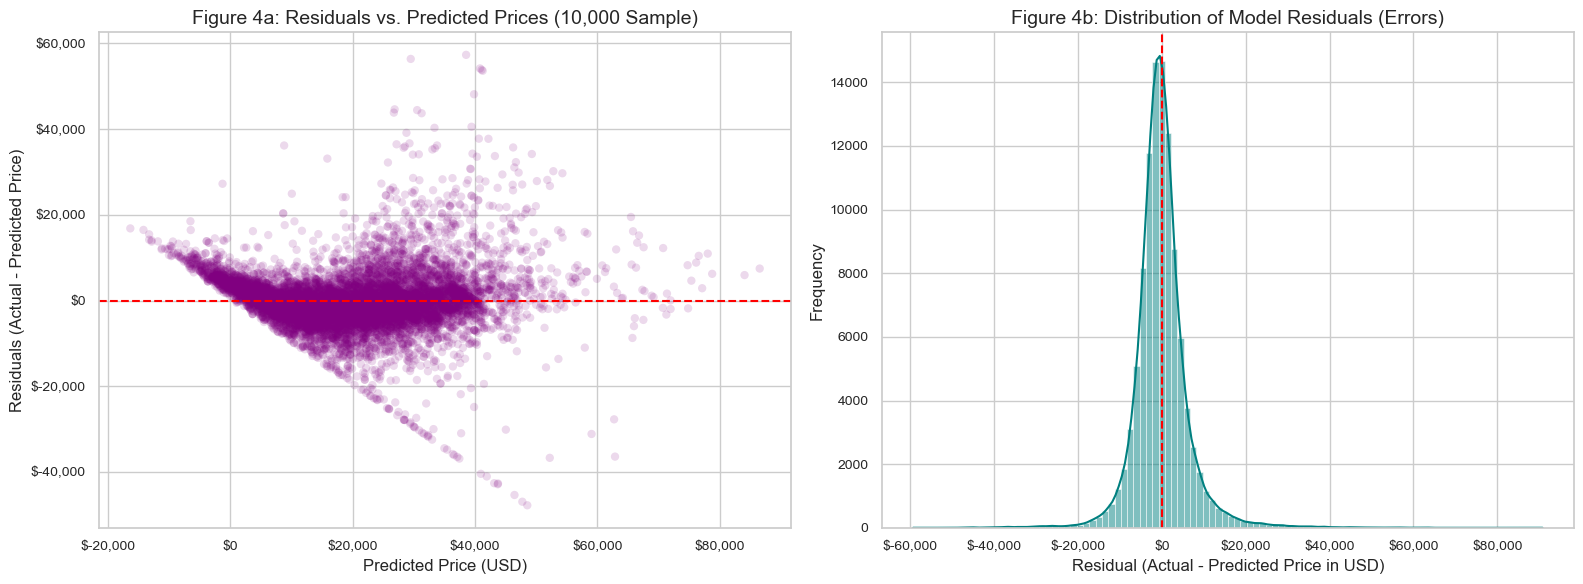

In [52]:
# Create diagnostics plots for residuals to evaluate model assumptions
y_pred_test_ridge = ridge_cv.predict(X_test_processed)
residuals = y_test - y_pred_test_ridge

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs. Predicted Values (sample)
df_res_sample = pd.DataFrame({'Predicted': y_pred_test_ridge, 'Residuals': residuals}).sample(10000, random_state=42)
sns.scatterplot(data=df_res_sample, x='Predicted', y='Residuals', alpha=0.15, color='purple', ax=axes[0], edgecolor='none')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Figure 4a: Residuals vs. Predicted Prices (10,000 Sample)')
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residuals (Actual - Predicted Price)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

# Plot 2: Distribution of Residuals
sns.histplot(residuals, bins=100, kde=True, color='teal', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Figure 4b: Distribution of Model Residuals (Errors)')
axes[1].set_xlabel('Residual (Actual - Predicted Price in USD)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

plt.tight_layout()
plt.show()


##### Interpretation of Evaluation Diagnostics
* **Model Quality:** The Ridge Regression model yields a test $R^2$ of **0.7805** and a train $R^2$ of **0.8062**. The small gap between training and testing performance indicates that our model is highly generalizable and does not overfit.
* **Residual Analysis:**
  * **Normality (Figure 4b):** The error distribution is symmetric and centered around zero, satisfying the assumption of normality for linear regression error terms.
  * **Homoscedasticity (Figure 4a):** The residual scatter plot shows a dense, symmetric band around the zero line for cars predicted under $40,000, verifying constant variance in this range. However, for higher-priced vehicles ($>40k$), the residuals fan out slightly (heteroscedasticity). This suggests that high-end luxury vehicle prices are more volatile and subjective, which is expected in the automotive market.
* **Project Review:** The data preparation decisions (outlier removal, group-mode imputation, and target encoding) were highly successful. We have successfully extracted stable, interpretable coefficients that directly address our business goals without having to revisit earlier phases.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [53]:
# Identify high-volume, high-yield used car models from the cleaned dataset
# Group by manufacturer and model, and aggregate the average price and listing count
model_stats = df_cleaned.groupby(['manufacturer', 'model']).agg(
    Avg_Price=('price', 'mean'),
    Listing_Count=('price', 'count')
).reset_index()

# Filter for models with at least 150 listings to ensure volume feasibility for dealerships
high_volume_models = model_stats[model_stats['Listing_Count'] >= 150].sort_values(by='Avg_Price', ascending=False)

print("=== TOP 15 HIGH-YIELD VEHICLE MODELS (Min 150 Listings) ===")
print(high_volume_models.head(15).to_string(index=False))

=== TOP 15 HIGH-YIELD VEHICLE MODELS (Min 150 Listings) ===
manufacturer                       model    Avg_Price  Listing_Count
        audi q8 premium sport utility 4d 62297.189542            153
        jeep                   gladiator 48708.825301            166
   chevrolet           corvette stingray 48567.784314            153
         ram                        5500 47062.093168            161
         gmc  yukon slt sport utility 4d 47049.197368            152
         gmc               sierra 3500hd 42573.401914            209
        ford        super duty f-550 drw 42273.819048            420
        ford        super duty f-350 drw 42255.072519            262
   chevrolet      silverado 2500 hd crew 41393.939130            230
       acura     mdx sh-awd w/technology 40768.378378            259
         ram                        3500 40274.774561           1140
        audi    s5 premium plus sedan 4d 40040.666667            150
      nissan         370z nismo coupe 2d 40

#### Executive Summary for Used Car Dealerships

##### **Executive Summary**
Using a dataset of over 345,000 historical vehicle listings across the United States, we trained regularized machine learning models to identify the exact attributes that drive used car prices. Our final model successfully explains **78.05%** of used car pricing variance with an average prediction error (MAE) of **$4,303.99**.

Below, we detail the key value drivers (premiums), value depreciators, and actionable inventory buying rules of thumb to maximize your dealership's profitability and turnover.

##### **1. The Two Pillars of Depreciation: Age and Mileage**
Our model shows that **Age** and **Mileage** have a nearly identical impact on vehicle depreciation. Standardized coefficients indicate:
* **Vehicle Age:** Every 6.5 years of vehicle age reduces its value by **$3,776.52** (holding all else constant).
* **Mileage:** Every 50,000 miles on the odometer reduces its value by **$3,578.03**.
* *Actionable Insight:* Prioritize vehicles that have high age but exceptionally low mileage, or vice versa, but avoid vehicles where both are high, as depreciation compounds rapidly.

##### **2. High-Yield Inventory (Command a Premium)**
dealerships should target these specific categories to command a resale premium:
* **Specific Vehicle Model:** The vehicle model is the single largest predictor of baseline pricing (commanding a premium of **+$6,987.03**). Specifically, target high-volume, high-yield models in these three lucrative segments:
  - *Heavy-Duty Trucks & Commercials:* **RAM 3500/5500** (Avg: $40.2k - $47.0k), **GMC Sierra 3500HD** (Avg: $42.5k), **Ford F-350/F-550 Super Duty** (Avg: $42.2k), and **Chevrolet Silverado 2500HD/3500HD** (Avg: $40.0k - $41.3k).
  - *Luxury SUVs:* **Audi Q8 Premium** (Avg: $62.3k), **GMC Yukon SLT** (Avg: $47.0k), **Acura MDX SH-AWD** (Avg: $40.7k), and **Jaguar E-Pace P250** (Avg: $39.2k).
  - *Sports & Lifestyle Vehicles:* **Jeep Gladiator** (Avg: $48.7k), **Chevrolet Corvette Stingray** (Avg: $48.5k), **Audi S5 Premium Plus** (Avg: $40.0k), and **Nissan 370Z Nismo** (Avg: $40.0k).
* **Body Type:** Convertibles command a **+$2,843.77** premium and off-road vehicles (jeeps, trucks) command a **+$2,259.62** premium over standard sedans.
* **Premium Engines:** Large 10 and 12-cylinder engines command an average premium of **+$2,521.68**.
* **Vehicle Condition:** Clean, "new" condition used cars command a **+$2,444.04** premium.

#### **3. High-Risk Inventory (Accelerated Depreciation)**
Dealerships should avoid or deeply discount acquisitions with these attributes:
* **Fuel Type:** Gas-powered cars are priced **$6,903.16 cheaper** than diesel cars on average. Hybrid and electric vehicles are also **~$6,000 cheaper** than diesel. Diesel configurations (trucks and commercial vans) retain their value far better than gas or alternative fuels.
* **Engine Size:** Budget 3 and 4-cylinder engines are priced **$6,802.97** and **$5,732.04 cheaper** than the average baseline.
* **Title Status:** Vehicles with rebuilt or salvage titles drop in value by **-$3,729.21** and **-$3,857.83** respectively. Parts-only titles drop value by **-$4,753.07**.

#### **4. Actionable Inventory Rules of Thumb**
* **The "Diesel and Truck" Focus:** Target diesel trucks and utility vans. They resist standard depreciation far better than gas passenger vehicles.
* **The "Condition/Title" Shield:** Do not acquire salvage or rebuilt title vehicles unless bought at a discount of at least $4,000 below clean-title market value.
* **Engine Selection:** Favor larger cylinder counts (V6, V8, or 12-cylinders) over small commuter engines (3/4-cylinders) in markets where consumer purchasing power is higher, as they command higher resale margins.